In [24]:
from tqec.computation.prism import BasisPrism, Position3DHex, ZXPrism
from tqec.computation.pipe_prism import PrismPipeKind
from tqec.computation.prism_graph import PrismGraph
from tqec.computation.correlation import find_correlation_surfaces

import tqec.computation.syndrome_extraction_cc as se

import mqt.qecc

import temp_utils

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [25]:
g = PrismGraph("red junction")

prisms = [
    (Position3DHex(0,0,1), "NN", "middle"),
    (Position3DHex(0,0,2), "NZ", "top"),
    (Position3DHex(0,0,0), "ZN", "bottom"),
    (Position3DHex(1,1,1), "XX", "left"),
    (Position3DHex(-1,1,1), "XX", "right"),
    (Position3DHex(1,-1,1), "XX", "down"),
]

for pos, kind, label in prisms:
    g.add_prism(pos, kind, label)


In [26]:
#middle bottom
pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[0][0], prisms[2][0], pipe_kind)

#middle top
pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[0][0], prisms[1][0], pipe_kind)

#middle left
pipe_kind = PrismPipeKind(hor = BasisPrism.X, ver = BasisPrism.Z)
g.add_pipe(prisms[0][0], prisms[3][0], pipe_kind)

#middle right
pipe_kind = PrismPipeKind(hor = BasisPrism.X, ver = BasisPrism.Z)
g.add_pipe(prisms[0][0], prisms[4][0], pipe_kind)

#middle down
pipe_kind = PrismPipeKind(hor = BasisPrism.X, ver = BasisPrism.Z)
g.add_pipe(prisms[0][0], prisms[5][0], pipe_kind)

In [27]:
g.view_as_html()

In [28]:
z=0
d=7
stabs_x, stabs_z, _, _, _ = g.stabilizers_timeslice(z,d)

In [29]:
z=1
d=7
stabs_x, stabs_z, _, dct_single_type_stabs, dct_patch_stabilizers, = g.stabilizers_timeslice(z,d)

In [18]:
z=2
d=7
stabs_x, stabs_z, _, _, _ = g.stabilizers_timeslice(z,d)

/mnt/c/Users/Laura/Documents/Codes_and_Repos/tqec_cococo/tqec/temp-laura/temp_utils.py:121: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


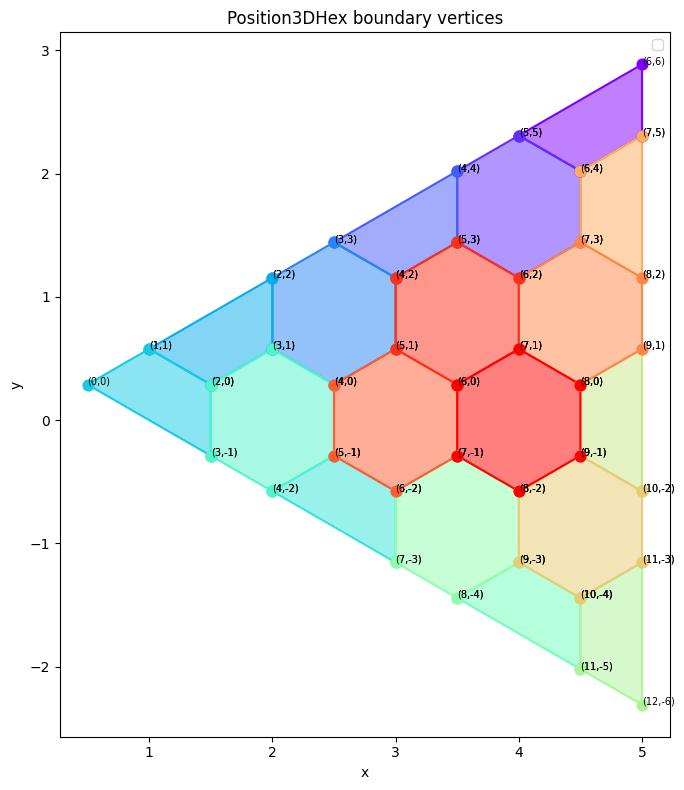

In [19]:
temp_utils.plot_position_dict(size = (8,8),stabilizers=stabs_x)

In [20]:
stabs_z[0]

[Position3DHex(x=6, y=6, z=2),
 Position3DHex(x=5, y=5, z=2),
 Position3DHex(x=6, y=4, z=2),
 Position3DHex(x=7, y=5, z=2)]

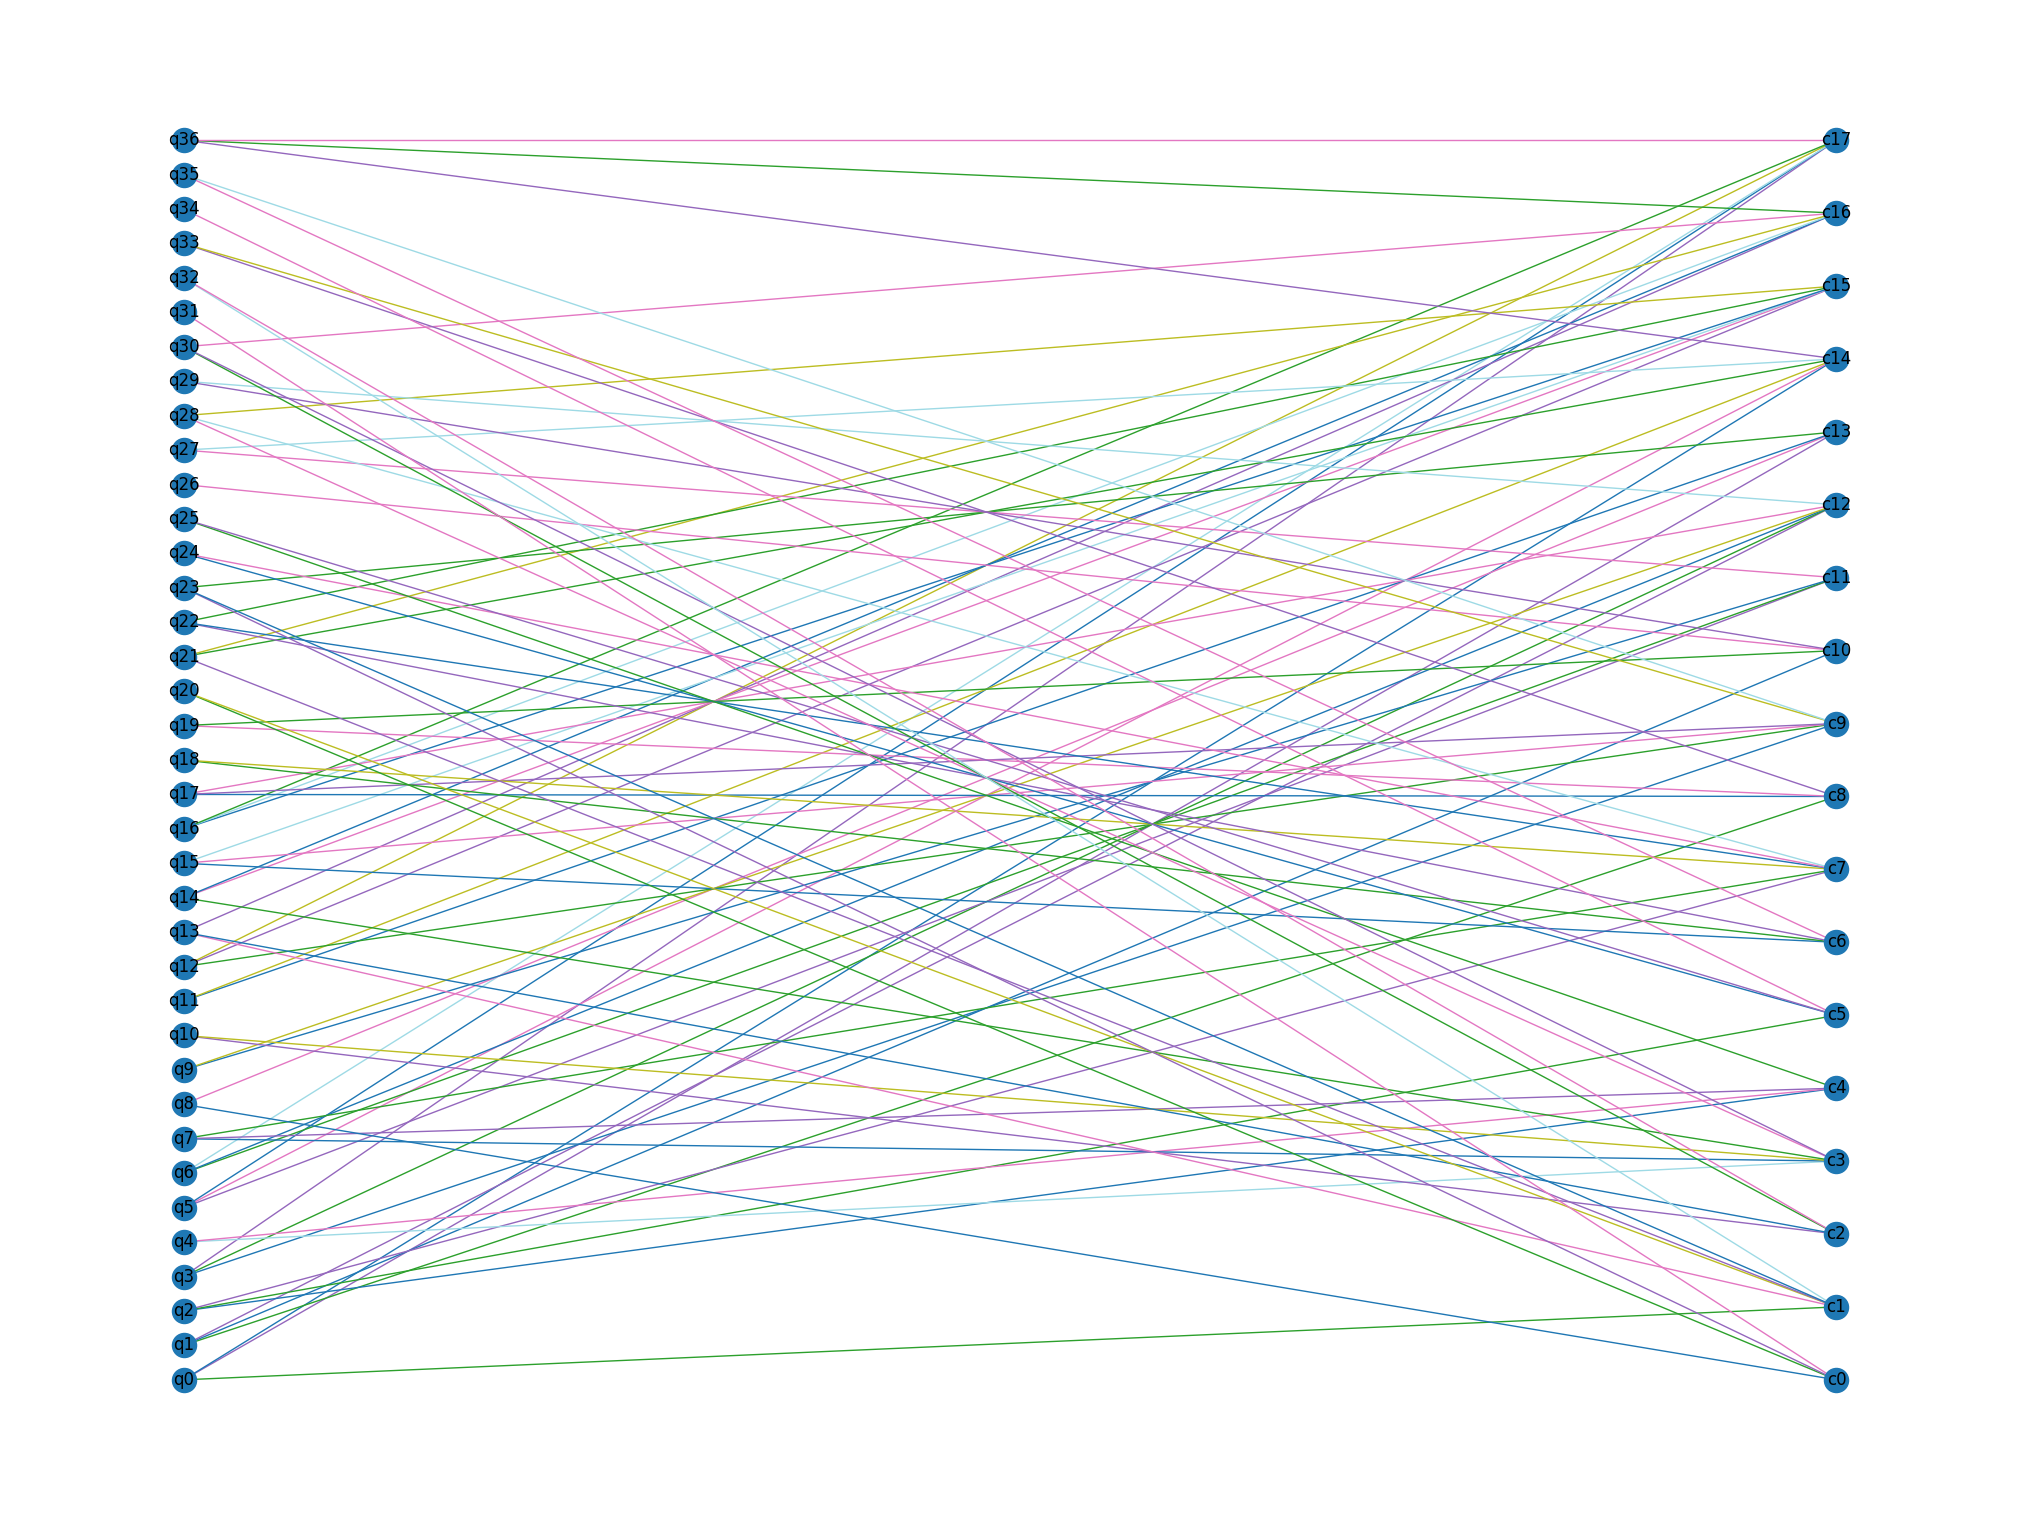

In [10]:
stabs = stabs_z
#find position to integer mapping
#flatten the positions
positions = list(set([item for sublist in stabs for item in sublist]))
mapping = {value: key for key,value in enumerate(positions)}

#find check matrix
def check_matrix(stabs, mapping):
    """create check matrix given some stabilizers and a mapping"""
    cols = len(mapping)
    rows = len(stabs)
    arr = np.zeros((rows, cols), dtype = int)
    for k,stab in enumerate(stabs):
        stab_int = [mapping[pos] for pos in stab]
        for label in stab_int:
            arr[k, label] = 1

    return arr

arr = check_matrix(stabs, mapping)

#create tanner graph
def tanner_graph(arr):
    """given a check matrix, create a tanner graph."""
    rows, cols = arr.shape

    G = nx.Graph()

    # qubit nodes
    G.add_nodes_from([f"q{i}" for i in range(cols)])
    # check nodes
    G.add_nodes_from([f"c{i}" for i in range(rows)])

    for i in range(rows):
        for j in range(cols):
            if arr[i, j] == 1:
                G.add_edge(f"c{i}", f"q{j}")

    return G

G = tanner_graph(arr)

#PLOT
q_nodes = [f"q{i}" for i in range(np.shape(arr)[1])]

# compute layout
pos = nx.bipartite_layout(G, q_nodes)

# draw
#plt.figure(figsize=(20,15))  # width, height in inches
#nx.draw(G, pos, with_labels=True)
#plt.show()

#for node, deg in G.degree():
#    if node.startswith("q"):
#        print(f"{node} (qubit): {deg}")
#    else:
#        print(f"{node} (check): {deg}")


#-----------create coloring of tanner graph-------------

# Step 1: line graph
L = nx.line_graph(G)

# Step 2: color nodes of line graph
edge_coloring = nx.coloring.greedy_color(L, strategy="largest_first")


#display graph
edge_colors = [edge_coloring[edge] for edge in G.edges]

plt.figure(figsize=(20, 15))
nx.draw(G, pos, with_labels=True, edge_color=edge_colors, edge_cmap=plt.cm.tab20)
plt.show()

In [11]:
max(edge_colors)+1

6

## example of single prism

In [1]:
from tqec.computation.prism import BasisPrism, Position3DHex, ZXPrism
from tqec.computation.pipe_prism import PrismPipeKind
from tqec.computation.prism_graph import PrismGraph
from tqec.computation.correlation import find_correlation_surfaces

import tqec.computation.syndrome_extraction_cc as se

import mqt.qecc

import temp_utils

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
g = PrismGraph("two-patches")

prisms = [
    (Position3DHex(0,0,0), "ZZ", "middle"),
    #(Position3DHex(1,1,0), "ZZ", "left"),
]

for pos, kind, label in prisms:
    g.add_prism(pos, kind, label)

#middle bottom
#pipe_kind = PrismPipeKind(hor = BasisPrism.Z, ver = BasisPrism.X)
#g.add_pipe(prisms[0][0], prisms[1][0], pipe_kind)

g.view_as_html()


In [3]:
z=0
d=3
stabs_x, stabs_z, _, dct_single_type_stabs, dct_patch_stabilizers, = g.stabilizers_timeslice(z,d)

In [4]:
#star_ops_x, star_ops_z = g.star_operator_timeslice(z, d)
#print(len(star_ops_x), len(star_ops_z))

/mnt/c/Users/Laura/Documents/Codes_and_Repos/tqec_cococo/tqec/temp-laura/temp_utils.py:169: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


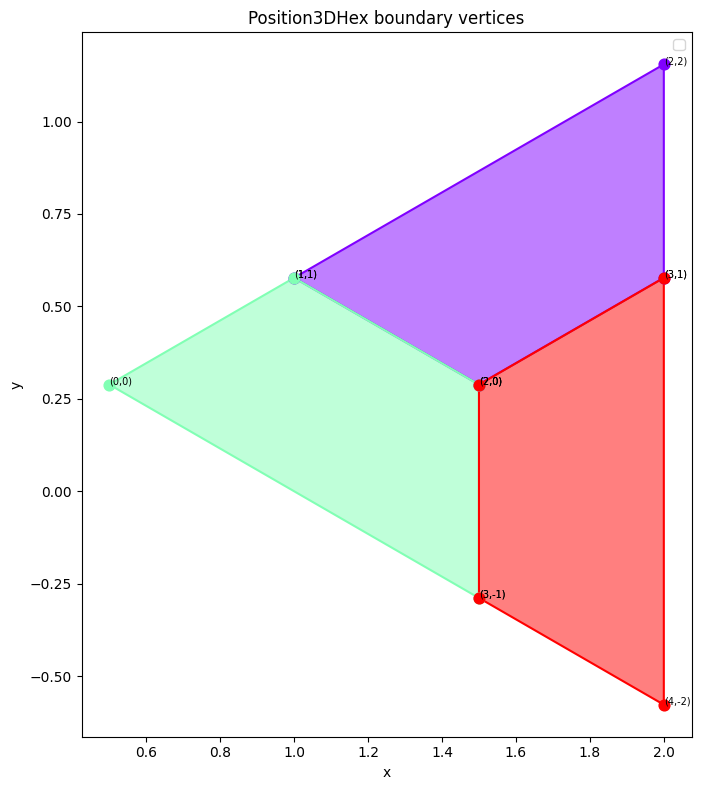

In [5]:
temp_utils.plot_position_dict(size = (8,8),stabilizers=stabs_z)#, star_op=star_ops_z)

In [6]:
#all_paths_stabilizer_product = result.stabilizer_products_x
#assignment = result.assignment#
#all_paths_stars = result.stars_x
#all_paths = result.paths_x
#idx = 0
#for el in all_paths[idx]:
#    print(el)
#temp_utils.plot_position_dict_3color(size = (8,8), color_assignment=assignment, stabilizer_product = all_paths_stabilizer_product[idx], star_operators = all_paths_stars[idx], show_positions = True)

In [7]:

SE = se.SyndromeExtractionStimCC(g, d=d)

rounds = 2
after_clifford_depolarization =0.0
before_round_data_depolarization =0.0
after_reset_flip_probability = 0.0
before_measure_flip_probability = 0.0

circuit = SE.run_all(
    rounds,
    after_clifford_depolarization,
    before_round_data_depolarization,
    after_reset_flip_probability,
    before_measure_flip_probability
)


self.mapping:
{Position3DHex(x=3, y=-1, z=0): 0, Position3DHex(x=1, y=1, z=0): 1, Position3DHex(x=2, y=0, z=0): 2, Position3DHex(x=4, y=-2, z=0): 3, Position3DHex(x=0, y=0, z=0): 4, Position3DHex(x=3, y=1, z=0): 5, Position3DHex(x=2, y=2, z=0): 6}
self.mapping_ancillas
{(Position3DHex(x=1, y=1, z=0), Position3DHex(x=2, y=0, z=0), Position3DHex(x=2, y=2, z=0), Position3DHex(x=3, y=1, z=0)): 7, (Position3DHex(x=0, y=0, z=0), Position3DHex(x=1, y=1, z=0), Position3DHex(x=2, y=0, z=0), Position3DHex(x=3, y=-1, z=0)): 8, (Position3DHex(x=2, y=0, z=0), Position3DHex(x=3, y=-1, z=0), Position3DHex(x=3, y=1, z=0), Position3DHex(x=4, y=-2, z=0)): 9}
building circuit for z=0...
initialization Z, ZZPosition3DHex(x=0, y=0, z=0)
len stabs_x 3
len stabs_z 3
No horizontal CS available for d<=5. your circuit will be wrong.
stabilizer_product_x init None
stabilizer_product_x ancillas None
horizontal_cs_x []
stabilizer_product_z init None
stabilizer_product_z ancillas None
horizontal_cs_z []
Z detector 

In [8]:
svg = circuit.diagram("timeline-svg")
with open("circuit.svg", "w") as f:
    f.write(str(svg))

In [8]:

# sample the logical observable directly
sampler = circuit.compile_sampler()
results = sampler.sample(shots=10)
print(results)  # should be all the same value

# alternatively, use the detector sampler to check no detectors fire
det_sampler = circuit.compile_detector_sampler()
det_results, obs_results = det_sampler.sample(shots=100, separate_observables=True)
print("Any detectors fired?", det_results.any())   # should be False
print("Observable values:", obs_results)            # should be all same value

[[False  True False False False False False  True False False False False
   True False False  True  True  True False]
 [False  True False False False False False  True False False False False
  False False False False False False False]
 [False  True False False False False False  True False False False False
   True  True False False False  True  True]
 [ True False  True False False False  True False  True False False False
   True False False  True  True  True False]
 [ True  True  True False False False  True  True  True False False False
  False  True  True  True False  True False]
 [ True False False False False False  True False False False False False
   True  True  True False  True False False]
 [False False False False False False False False False False False False
   True False  True  True False False  True]
 [ True False False False False False  True False False False False False
   True  True False False False  True  True]
 [ True  True  True False False False  True  Tru

In [14]:
#----hard coded logical measurement outcomes-------

k = 7
z_l_bits = results[:, -k:]
z_l_raw = np.bitwise_xor.reduce(z_l_bits, axis=1)
print("Z_L raw:", z_l_raw)
print("Deterministic:", np.all(z_l_raw == z_l_raw[0]))


#-----------automatized with in built OBS from stim-------------
#only works with compile detector sampler

num_obs = circuit.num_observables
obs = det_results[:, -num_obs:]

z_l_raw = obs[:, 0]   # first observable

print("num_measurements:", circuit.num_measurements)
print("num_observables:", circuit.num_observables)
print("sample shape:", det_results.shape)

print("Z_L raw:", z_l_raw)
print("Deterministic:", np.all(z_l_raw == z_l_raw[0]))

Z_L raw: [False False False False False False False False False False]
Deterministic: True
num_measurements: 19
num_observables: 1
sample shape: (100, 12)
Z_L raw: [False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False]
Deterministic: True


## run with sinter

In [11]:
d_lst = [3,5]
circuit_builders = [se.SyndromeExtractionStimCC(g, d=d) for d in d_lst]

op_3 = [#transversal z ,d=3
    Position3DHex(x=0, y=0, z=0),
    Position3DHex(x=1, y=1, z=0),
    Position3DHex(x=2, y=2, z=0),
    Position3DHex(x=2, y=0, z=0),
    Position3DHex(x=3, y=1, z=0),
    Position3DHex(x=3, y=-1, z=0),
    Position3DHex(x=4, y=-2, z=0)
]

#!change this if you use more than just a single prism
z=0
d=5
stabs_x, stabs_z, _, dct_single_type_stabs, dct_patch_stabilizers, = g.stabilizers_timeslice(z,d)
op_5 = list(set([item for sublist in stabs_x for item in sublist])) 


logical_operators = [
    op_3,
    op_5,
]

p_values = list(np.round(np.geomspace(0.0005, 0.02, 10), 6))

rounds = 5 #!ADAPT THIS TO d

stats = se.run_experiment_sinter(
    circuit_builders,
    logical_operators,
    rounds,
    p_values,
)

Starting 2 workers...
20 tasks left:
  workers   decoder eta shots_left errors_left json_metadata                 
        1 tesseract  3m       9999         100 p=0.0005,rounds=5,code_idx=0  
        1 tesseract   ?      10000         100 p=0.000753,rounds=5,code_idx=0
        0 tesseract ?·∞      10000         100 p=0.001135,rounds=5,code_idx=0
        0 tesseract ?·∞      10000         100 p=0.00171,rounds=5,code_idx=0 
        0 tesseract ?·∞      10000         100 p=0.002576,rounds=5,code_idx=0
        0 tesseract ?·∞      10000         100 p=0.003882,rounds=5,code_idx=0
        0 tesseract ?·∞      10000         100 p=0.005848,rounds=5,code_idx=0
        0 tesseract ?·∞      10000         100 p=0.008811,rounds=5,code_idx=0
        0 tesseract ?·∞      10000         100 p=0.013275,rounds=5,code_idx=0
        0 tesseract ?·∞      10000         100 p=0.02,rounds=5,code_idx=0    
        0 tesseract ?·∞      10000         100 p=0.0005,rounds=5,code_idx=1  
        0 tesseract ?·∞    

In [14]:
import sinter
def plot_experiment_sinter(stats: list[sinter.TaskStats], d_lst: list[int]):
    fig, ax = plt.subplots()

    sinter.plot_error_rate(
        ax=ax,
        stats=stats,
        x_func=lambda stat: stat.json_metadata['p'],
        group_func=lambda stat: f"d={d_lst[stat.json_metadata['code_idx']]}",
    )

    ax.set_xlabel("Physical error rate p")
    ax.set_ylabel("Logical error rate")
    ax.set_title("Logical error rate vs physical error rate")
    ax.loglog()
    ax.grid(True, which='both', ls='--', alpha=0.5)
    ax.legend(title="Code distance")
    plt.tight_layout()
    plt.show()

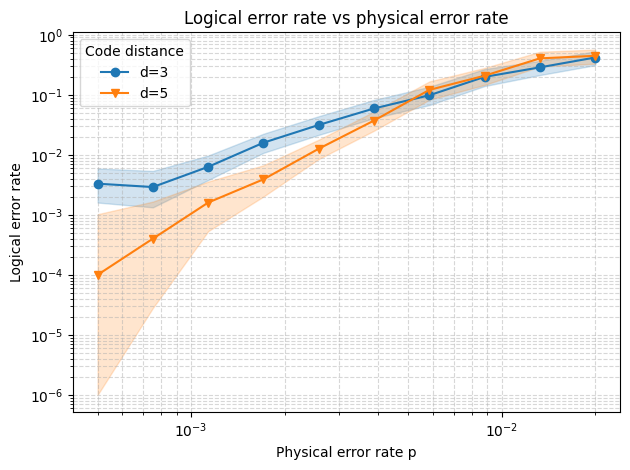

In [15]:
plot_experiment_sinter(stats, d_lst)

## teleportation

In [1]:
from tqec.computation.prism import BasisPrism, Position3DHex, ZXPrism
from tqec.computation.pipe_prism import PrismPipeKind
from tqec.computation.prism_graph import PrismGraph
from tqec.computation.correlation import find_correlation_surfaces

import tqec.computation.syndrome_extraction_cc as se


import temp_utils

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [16]:
g = PrismGraph("two-patches")

prisms = [
    (Position3DHex(0,0,-1), "ZN", "init"),
    (Position3DHex(0,0,0), "NZ", "left"),
    (Position3DHex(1,1,0), "ZN", "right"),
    (Position3DHex(1,1,1), "NZ", "final"),
]

for pos, kind, label in prisms:
    g.add_prism(pos, kind, label)

pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[0][0], prisms[1][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.Z, ver = BasisPrism.X)
g.add_pipe(prisms[1][0], prisms[2][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[2][0], prisms[3][0], pipe_kind)


#------------------------------

#g = PrismGraph("two-patches")

#prisms = [
#    (Position3DHex(0,0,-1), "ZN", "init"),
#    (Position3DHex(0,0,0), "NZ", "left"),
#    (Position3DHex(1,1,0), "ZN", "right"),
#    (Position3DHex(1,1,1), "NZ", "final"),
#]

#for pos, kind, label in prisms:
#    g.add_prism(pos, kind, label)

#pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
#g.add_pipe(prisms[0][0], prisms[1][0], pipe_kind)

#pipe_kind = PrismPipeKind(hor = BasisPrism.Z, ver = BasisPrism.X)
#g.add_pipe(prisms[1][0], prisms[2][0], pipe_kind)

#pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
#g.add_pipe(prisms[2][0], prisms[3][0], pipe_kind)


#----memory--------

#g = PrismGraph("two-patches")
#prisms = [
#    (Position3DHex(0,0,0), "ZZ", "middle"),
#    #(Position3DHex(1,1,0), "ZZ", "left"),
#]
#for pos, kind, label in prisms:
#    g.add_prism(pos, kind, label)

g.view_as_html()


In [17]:
z=-1
d=3
stabs_x, stabs_z, _, dct_single_type_stabs, dct_patch_stabilizers, = g.stabilizers_timeslice(z,d)

star_ops_x, star_ops_z = g.star_operator_timeslice(z, d)
print(len(star_ops_x), len(star_ops_z))

#temp_utils.plot_position_dict(size = (8,8),stabilizers=stabs_z, star_op=star_ops_x)


1 1


0 1


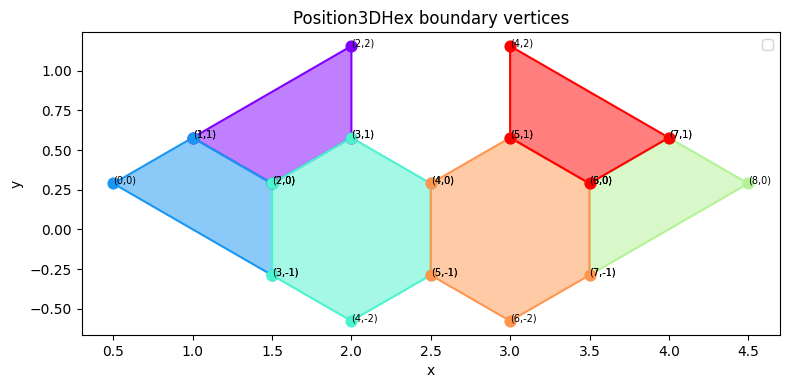

In [18]:
z=0
d=3
stabs_x, stabs_z, _, dct_single_type_stabs, dct_patch_stabilizers, = g.stabilizers_timeslice(z,d)

star_ops_x, star_ops_z = g.star_operator_timeslice(z, d)
print(len(star_ops_x), len(star_ops_z))

temp_utils.plot_position_dict(size = (8,8),stabilizers=stabs_z, star_op=star_ops_x)


In [19]:
z=1
d=3
stabs_x, stabs_z, _, dct_single_type_stabs, dct_patch_stabilizers, = g.stabilizers_timeslice(z,d)

star_ops_x, star_ops_z = g.star_operator_timeslice(z, d)
print(len(star_ops_x), len(star_ops_z))

#temp_utils.plot_position_dict(size = (8,8),stabilizers=stabs_z, star_op=star_ops_x)


1 1


In [20]:
z=0
d=3
stabs_x, stabs_z, _, dct_single_type_stabs, dct_patch_stabilizers, = g.stabilizers_timeslice(z,d)

result = g.stabilizer_product_timeslice(z, d, dct_single_type_stabs, dct_patch_stabilizers, testing = True)
print(len(result.stabilizer_products_x), len(result.stabilizer_products_z))

all_paths_stabilizer_product = result.stabilizer_products_z
assignment = result.assignment#
all_paths_stars = result.stars_z
all_paths = result.paths_z
idx = 0
#for el in all_paths[idx]:
#    print(el)
#temp_utils.plot_position_dict_3color(size = (8,8), color_assignment=assignment, stabilizer_product = all_paths_stabilizer_product[idx], star_operators = all_paths_stars[idx], show_positions = True)

stabilizer tests passed
1 0


In [21]:
#SE = se.SyndromeExtractionStimCC(g, d=d)
#SE.retrieve_stabilizers_operators()
#final_prism = SE.prism_graph.prisms[3]
#logical_operator = SE.prism_graph.prism_pipes_to_data_qubits_full[1][final_prism] #prisms from diagram construction

In [29]:
d=9

SE = se.SyndromeExtractionStimCC(g, d=d)
#SE.retrieve_stabilizers_operators()
#final_prism = SE.prism_graph.prisms[3]
#logical_operator = SE.prism_graph.prism_pipes_to_data_qubits_full[1][final_prism] #prisms from diagram construction
#zfinal = 1
#logical_operator = [Position3DHex(x=el.x, y=el.y, z=zfinal) for el in logical_operator]

rounds = d
p = 0.0

circuit = SE.run_all(
    rounds,
    p,
    p,
    p,
    p
)


stabilizer tests passed
self.mapping:
{Position3DHex(x=9, y=3, z=0): 0, Position3DHex(x=4, y=0, z=0): 1, Position3DHex(x=11, y=-3, z=0): 2, Position3DHex(x=4, y=2, z=0): 3, Position3DHex(x=14, y=-6, z=0): 4, Position3DHex(x=6, y=6, z=0): 5, Position3DHex(x=4, y=4, z=0): 6, Position3DHex(x=8, y=-4, z=0): 7, Position3DHex(x=14, y=-4, z=0): 8, Position3DHex(x=15, y=-7, z=0): 9, Position3DHex(x=12, y=-2, z=0): 10, Position3DHex(x=11, y=3, z=0): 11, Position3DHex(x=11, y=1, z=0): 12, Position3DHex(x=0, y=0, z=0): 13, Position3DHex(x=9, y=5, z=0): 14, Position3DHex(x=7, y=-3, z=0): 15, Position3DHex(x=12, y=0, z=0): 16, Position3DHex(x=13, y=-5, z=0): 17, Position3DHex(x=9, y=7, z=0): 18, Position3DHex(x=13, y=-3, z=0): 19, Position3DHex(x=10, y=-4, z=0): 20, Position3DHex(x=7, y=1, z=0): 21, Position3DHex(x=7, y=3, z=0): 22, Position3DHex(x=2, y=0, z=0): 23, Position3DHex(x=8, y=-2, z=0): 24, Position3DHex(x=15, y=-5, z=0): 25, Position3DHex(x=2, y=2, z=0): 26, Position3DHex(x=11, y=-1, z=0

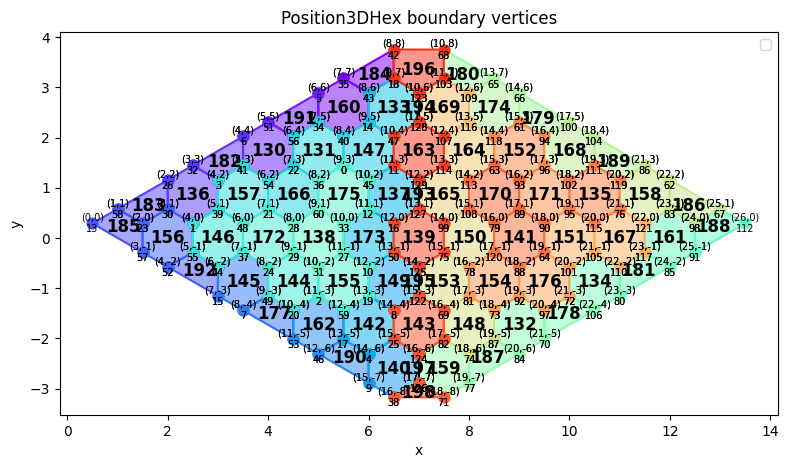

In [30]:
stabs_x, stabs_z = SE.result_dct[0]["stabs"]
mapping = SE.mapping
mapping_ancillas = SE.mapping_ancillas
temp_utils.plot_position_dict(size = (8,8),stabilizers=stabs_x, mapping=mapping, mapping_ancillas = mapping_ancillas)

In [31]:
svg = circuit.diagram("timeline-svg")
with open(f"circuit_d{d}.svg", "w") as f:
    f.write(str(svg))

In [32]:
N=100
# sample the logical observable directly
sampler = circuit.compile_sampler()
samples = sampler.sample(shots=N)
#print(samples)  # should be all the same value

# alternatively, use the detector sampler to check no detectors fire
det_sampler = circuit.compile_detector_sampler()
det_results, obs_results = det_sampler.sample(shots=N, separate_observables=True)
print("Any detectors fired?", det_results.any())   # should be False         
#print(det_results)

fired = det_results.any(axis=0)  # shape: (n_detectors,)
fired_indices = np.where(fired)[0]

print("Detectors that fired:", fired_indices)
for idx in fired_indices:
    print(f"  D{idx}: fired in {det_results[:, idx].sum()}/{N} shots")

Any detectors fired? False
Detectors that fired: []


In [33]:
num_obs = circuit.num_observables
obs = det_results[:, -num_obs:]

z_l_raw = obs[:, 0]   # first observable

print("num_measurements:", circuit.num_measurements)
print("num_observables:", circuit.num_observables)
print("sample shape:", det_results.shape)

print("Z_L raw:", z_l_raw)
print("Deterministic:", np.all(z_l_raw == z_l_raw[0]))

num_measurements: 2452
num_observables: 1
sample shape: (100, 2313)
Z_L raw: [False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False]
Deterministic: True


In [34]:
dem = circuit.detector_error_model()

for instruction in dem.flattened():
    if instruction.type == "error":
        detectors = [t for t in instruction.targets_copy() 
                     if t.is_relative_detector_id()]
        logicals = [t for t in instruction.targets_copy() 
                    if t.is_logical_observable_id()]
        
        if len(detectors) == 0:
            print(f"Undetected error (p={instruction.args_copy()[0]}):")
            print(f"  Flips observables: {logicals}")
            print(f"  Full instruction: {instruction}")

In [35]:
def resolve_rec_indices(missing_det_circuit, total_measurements):
    detectors = []
    
    for inst in missing_det_circuit.flattened():
        targets = [
            total_measurements + target.value
            for target in inst.targets_copy()
            if target.is_measurement_record_target
        ]
        if targets:
            detectors.append(targets)
    
    return detectors

# Usage:
res = circuit.missing_detectors(unknown_input=False)
detectors = resolve_rec_indices(res, circuit.num_measurements)
for i, d in enumerate(detectors):
    print(f"Detector {i}: {d}")

In [36]:
#add missing detectors to the circuit

circuit = circuit + res

In [ ]:
res = circuit.search_for_undetectable_logical_errors(
        dont_explore_detection_event_sets_with_size_above=6,
        dont_explore_edges_with_degree_above=9999,
        dont_explore_edges_increasing_symptom_degree=False,
    )

print(f"d={len(res)}")

ValueError: Failed to find any logical errors.
    WARNING: NO ERRORS. The circuit or detector error model didn't include any errors, making it vacuously impossible to find a logical error.

In [112]:
res = circuit.shortest_graphlike_error()
print(f"d={len(res)}")

d=4


# temp

In [ ]:
def create_mapping_ancillas(self):
    max_label = max(list(self.mapping.values()))

    union = []
    seen = set()

    for z in self.z_values:
        prism_pipes_data = self.prism_graph.prism_pipes_to_data_qubits_full[z]

        # first pass: prisms — weight-6 stabilizers only
        for pipe_prism, data_qubits in prism_pipes_data.items():
            if isinstance(pipe_prism, Prism):
                dq_set = {Position3DHex(q.x, q.y, 0) for q in data_qubits}
                for stab in self.dct_stabilizers_all[z].keys():
                    stab_flat = tuple(Position3DHex(x=p.x, y=p.y, z=0) for p in stab)
                    if len(stab_flat) == 6 and len(set(stab_flat) & dq_set) >= 4 and stab_flat not in seen:
                        union.append(stab_flat)
                        seen.add(stab_flat)

        # second pass: pipes — weight-2, 3, 5 stabilizers
                for pipe_prism, data_qubits in prism_pipes_data.items():
                    if isinstance(pipe_prism, PrismPipe):
                        dq_set = {Position3DHex(q.x, q.y, 0) for q in data_qubits}
                        for stab in self.dct_stabilizers_all[z].keys():
                            stab_flat = tuple(Position3DHex(x=p.x, y=p.y, z=0) for p in stab)
                            if len(stab_flat) not in (4, 6) and len(set(stab_flat) & dq_set) >= 1 and stab_flat not in seen:
                                union.append(stab_flat)
                                seen.add(stab_flat)

    # collect weight-4 separately
    weight4 = []
    seen_w4 = set()
    for z in self.z_values:
        for stab in self.dct_stabilizers_all[z].keys():
            stab_flat = tuple(Position3DHex(x=p.x, y=p.y, z=0) for p in stab)
            if len(stab_flat) == 4 and stab_flat not in seen_w4:
                weight4.append(stab_flat)
                seen_w4.add(stab_flat)

    # assign labels: weight-6 and weight-2 first in collected order
    mapping_ancillas = {}
    stab_sets = {stab: set(stab) for stab in union + weight4}
    current_label = max_label + 1

    for stab in union:
        mapping_ancillas[stab] = current_label
        current_label += 1

    # weight-4 inherits from parent weight-6 if subset, otherwise gets new label
    weight6 = [stab for stab in union if len(stab) == 6]
    for stab4 in weight4:
        assigned = False
        for stab6 in weight6:
            if stab_sets[stab4].issubset(stab_sets[stab6]):
                mapping_ancillas[stab4] = mapping_ancillas[stab6]
                assigned = True
                break
        if not assigned:
            mapping_ancillas[stab4] = current_label
            current_label += 1

    self.mapping_ancillas = mapping_ancillas

## CNOT Gate

In [1]:
from tqec.computation.prism import BasisPrism, Position3DHex, ZXPrism
from tqec.computation.pipe_prism import PrismPipeKind
from tqec.computation.prism_graph import PrismGraph
from tqec.computation.correlation import find_correlation_surfaces

import tqec.computation.syndrome_extraction_cc as se


import temp_utils

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
g = PrismGraph("CNOT")

prisms = [
    (Position3DHex(3,3,0), "XN", "target-int"),
    (Position3DHex(3,3,1), "NN", ""),
    (Position3DHex(3,3,2), "NN", ""),
    (Position3DHex(3,3,3), "NX", "target-out"),

    (Position3DHex(2,2,1), "XN", ""),
    (Position3DHex(2,2,2), "NZ", ""),

    (Position3DHex(1,3,0), "XN", "control-in"),
    (Position3DHex(1,3,1), "NN", ""),
    (Position3DHex(1,3,2), "NN", ""),
    (Position3DHex(1,3,3), "NX", "control-out"),

]

for pos, kind, label in prisms:
    g.add_prism(pos, kind, label)

#c temp
pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[0][0], prisms[1][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[1][0], prisms[2][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[2][0], prisms[3][0], pipe_kind)

#t temp
pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[6][0], prisms[7][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[7][0], prisms[8][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[8][0], prisms[9][0], pipe_kind)

#spatial pipes
pipe_kind = PrismPipeKind(hor = BasisPrism.X, ver = BasisPrism.Z)
g.add_pipe(prisms[1][0], prisms[4][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.Z, ver = BasisPrism.X)
g.add_pipe(prisms[8][0], prisms[5][0], pipe_kind)

#middle temp
pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[4][0], prisms[5][0], pipe_kind)

g.view_as_html()

In [3]:
d=3

SE = se.SyndromeExtractionStimCC(g, d=d)
#SE.retrieve_stabilizers_operators()
#final_prism = SE.prism_graph.prisms[3]
#logical_operator = SE.prism_graph.prism_pipes_to_data_qubits_full[1][final_prism] #prisms from diagram construction
#zfinal = 1
#logical_operator = [Position3DHex(x=el.x, y=el.y, z=zfinal) for el in logical_operator]

rounds = 2
p = 0.00

circuit = SE.run_all(
    rounds,
    p,
    p,
    p,
    p,
)

self.mapping:
{Position3DHex(x=9, y=-7, z=0): 0, Position3DHex(x=10, y=-10, z=0): 1, Position3DHex(x=10, y=-8, z=0): 2, Position3DHex(x=11, y=-7, z=0): 3, Position3DHex(x=12, y=-8, z=0): 4, Position3DHex(x=8, y=-6, z=0): 5, Position3DHex(x=11, y=-9, z=0): 6, Position3DHex(x=3, y=-3, z=0): 7, Position3DHex(x=2, y=-6, z=0): 8, Position3DHex(x=1, y=-3, z=0): 9, Position3DHex(x=3, y=-5, z=0): 10, Position3DHex(x=0, y=-2, z=0): 11, Position3DHex(x=4, y=-4, z=0): 12, Position3DHex(x=2, y=-4, z=0): 13, Position3DHex(x=7, y=-7, z=0): 14, Position3DHex(x=5, y=-7, z=0): 15, Position3DHex(x=7, y=-9, z=0): 16, Position3DHex(x=8, y=-10, z=0): 17, Position3DHex(x=6, y=-6, z=0): 18, Position3DHex(x=4, y=-8, z=0): 19, Position3DHex(x=6, y=-8, z=0): 20, Position3DHex(x=8, y=-8, z=0): 21, Position3DHex(x=9, y=-9, z=0): 22, Position3DHex(x=5, y=-5, z=0): 23, Position3DHex(x=4, y=-6, z=0): 24}
self.mapping_ancillas
{(Position3DHex(x=8, y=-8, z=0), Position3DHex(x=9, y=-9, z=0), Position3DHex(x=9, y=-7, z=

In [ ]:
svg = circuit.diagram("timeline-svg")
with open(f"circuit_cnot_d{d}_b.svg", "w") as f:
    f.write(str(svg))

/mnt/c/Users/Laura/Documents/Codes_and_Repos/tqec_cococo/tqec/temp-laura/temp_utils.py:170: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


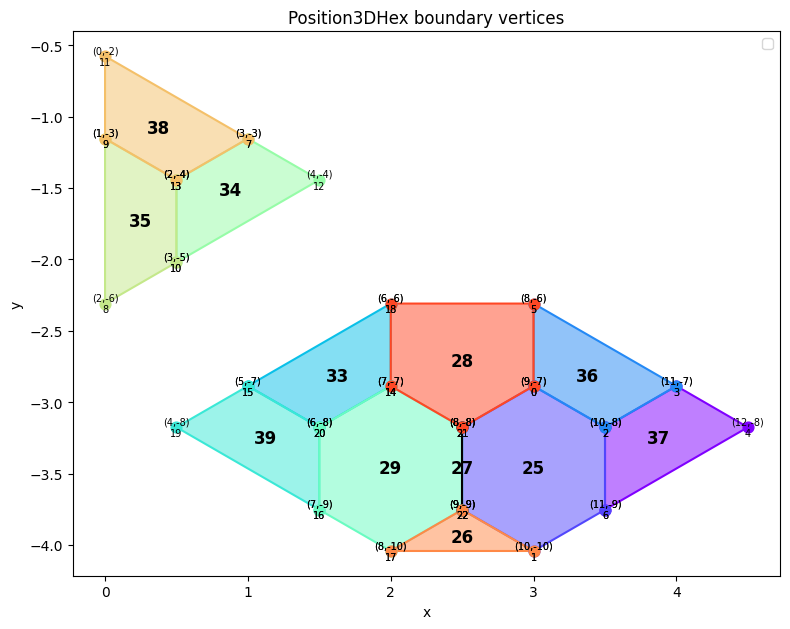

In [4]:
stabs_x, stabs_z = SE.result_dct[1]["stabs"]
mapping = SE.mapping
mapping_ancillas = SE.mapping_ancillas
temp_utils.plot_position_dict(size = (8,8),stabilizers=stabs_z, mapping=mapping, mapping_ancillas = mapping_ancillas)

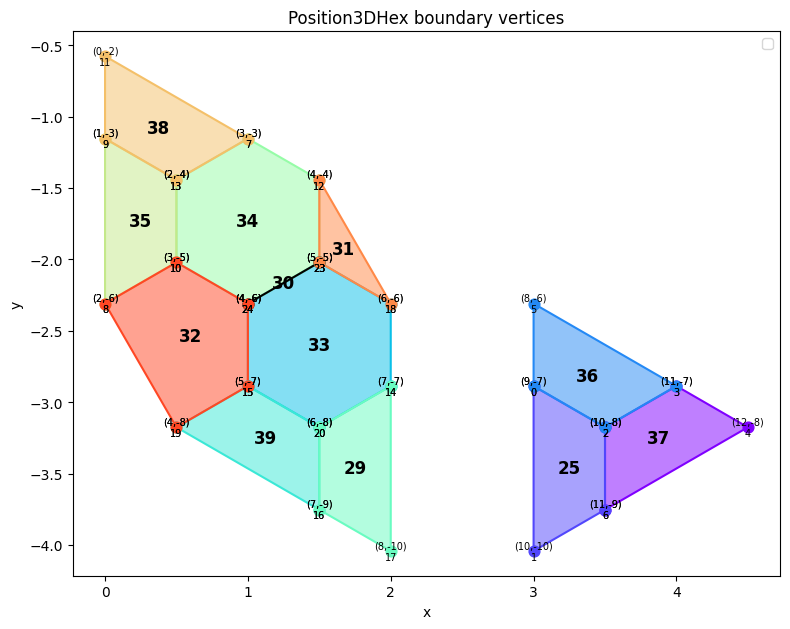

In [5]:
stabs_x, stabs_z = SE.result_dct[2]["stabs"]
mapping = SE.mapping
mapping_ancillas = SE.mapping_ancillas
temp_utils.plot_position_dict(size = (8,8),stabilizers=stabs_x, mapping=mapping, mapping_ancillas = mapping_ancillas)

In [17]:
print(mapping.values())
print("-----")
print(mapping_ancillas.values())

dict_values([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24])
-----
dict_values([25, 26, 27, 28, 26, 29, 28, 25, 30, 31, 32, 33, 27, 34, 35, 36, 37, 38, 39])


In [18]:
N=100
# sample the logical observable directly
sampler = circuit.compile_sampler()
samples = sampler.sample(shots=N)
#print(samples)  # should be all the same value

# alternatively, use the detector sampler to check no detectors fire
det_sampler = circuit.compile_detector_sampler()
det_results, obs_results = det_sampler.sample(shots=N, separate_observables=True)
print("Any detectors fired?", det_results.any())   # should be False         
#print(det_results)

fired = det_results.any(axis=0)  # shape: (n_detectors,)
fired_indices = np.where(fired)[0]

print("Detectors that fired:", fired_indices)
for idx in fired_indices:
    print(f"  D{idx}: fired in {det_results[:, idx].sum()}/{N} shots")

Any detectors fired? True
Detectors that fired: [ 91  92  93  95  97  98  99 100 101 102 103 123 125 126]
  D91: fired in 55/100 shots
  D92: fired in 54/100 shots
  D93: fired in 50/100 shots
  D95: fired in 55/100 shots
  D97: fired in 55/100 shots
  D98: fired in 49/100 shots
  D99: fired in 48/100 shots
  D100: fired in 47/100 shots
  D101: fired in 49/100 shots
  D102: fired in 52/100 shots
  D103: fired in 61/100 shots
  D123: fired in 55/100 shots
  D125: fired in 59/100 shots
  D126: fired in 55/100 shots


In [19]:
num_obs = circuit.num_observables
obs = det_results[:, -num_obs:]

z_l_raw = obs[:, 0]   # first observable

print("num_measurements:", circuit.num_measurements)
print("num_observables:", circuit.num_observables)
print("sample shape:", det_results.shape)

print("Z_L raw:", z_l_raw)
print("Deterministic:", np.all(z_l_raw == z_l_raw[0]))

num_measurements: 169
num_observables: 1
sample shape: (100, 128)
Z_L raw: [False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False]
Deterministic: True


## MISC

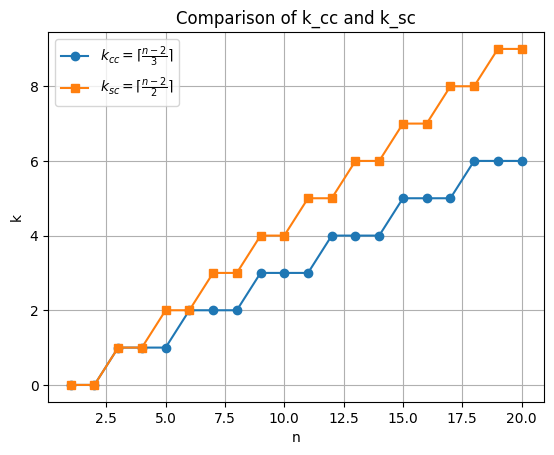

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Define range of n
n_values = np.arange(1, 21)

# Define functions
k_cc = [math.ceil((n - 2) / 3) for n in n_values]
k_sc = [math.ceil((n - 2) / 2) for n in n_values]

# Plot
plt.figure()
plt.plot(n_values, k_cc, marker='o', label=r'$k_{cc} = \lceil \frac{n-2}{3} \rceil$')
plt.plot(n_values, k_sc, marker='s', label=r'$k_{sc} = \lceil \frac{n-2}{2} \rceil$')

# Labels and title
plt.xlabel('n')
plt.ylabel('k')
plt.title('Comparison of k_cc and k_sc')
plt.legend()
plt.grid()

# Show plot
plt.show()

In [32]:
g = PrismGraph("red junction")

prisms = [
    (Position3DHex(0,0,1), "NN", "middle"),
    (Position3DHex(1,1,1), "NN", "middle"),
    (Position3DHex(-1,1,1), "NN", "middle"),

    (Position3DHex(0,0,0), "Port", "1"),
    (Position3DHex(1,1,0), "Port", "2"),
    (Position3DHex(-1,1,0), "Port", "3"),

    (Position3DHex(0,0,2), "Port", "4"),
    (Position3DHex(1,1,2), "Port", "5"),
    (Position3DHex(-1,1,2), "Port", "6"),

    (Position3DHex(2,0,1), "Port", "7"),
    (Position3DHex(-2,0,1), "Port", "8"),

    (Position3DHex(1,-1,1), "Port", "9"),
    (Position3DHex(0,2,1), "Port", "10"),
    (Position3DHex(-2,2,1), "Port", "11")

]

for pos, kind, label in prisms:
    g.add_prism(pos, kind, label)

horizontal_pipe = PrismPipeKind(hor=BasisPrism.X, ver=BasisPrism.Z)

# z = 1 (middle layer)
g.add_pipe(prisms[0][0], prisms[1][0], horizontal_pipe)  # (0,0,1) - (1,1,1)
g.add_pipe(prisms[0][0], prisms[2][0], horizontal_pipe)  # (0,0,1) - (-1,1,1)

# outer ports (only neighbors to center)
g.add_pipe(prisms[1][0], prisms[9][0], horizontal_pipe)   # (0,0,0) - (2,0,0)
g.add_pipe(prisms[2][0], prisms[10][0], horizontal_pipe)  # (0,0,0) - (-2,0,0)

#further
g.add_pipe(prisms[0][0], prisms[11][0], horizontal_pipe)
g.add_pipe(prisms[1][0], prisms[12][0], horizontal_pipe)
g.add_pipe(prisms[2][0], prisms[13][0], horizontal_pipe)


vertical_pipe = PrismPipeKind(hor=BasisPrism.N, ver=BasisPrism.N)

# center column
g.add_pipe(prisms[3][0], prisms[0][0], vertical_pipe)
g.add_pipe(prisms[0][0], prisms[6][0], vertical_pipe)

# right column
g.add_pipe(prisms[4][0], prisms[1][0], vertical_pipe)
g.add_pipe(prisms[1][0], prisms[7][0], vertical_pipe)

# left column
g.add_pipe(prisms[5][0], prisms[2][0], vertical_pipe)
g.add_pipe(prisms[2][0], prisms[8][0], vertical_pipe)

g.view_as_html()

(<Figure size 500x600 with 1 Axes>, <Axes3D: >)

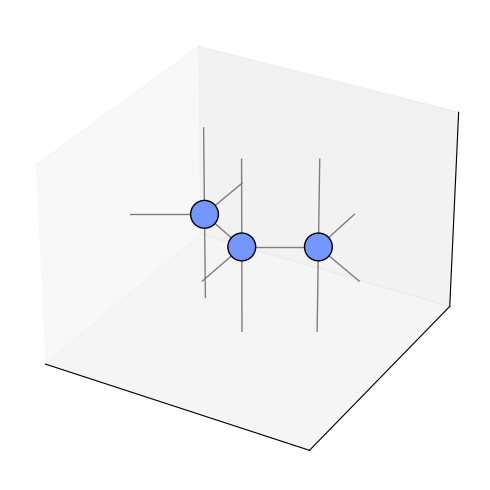

In [33]:
zx = g.to_zx_graph()
zx.draw()